<a href="https://colab.research.google.com/github/MarioDLCruz/PolisemiaV1/blob/main/umap1k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import umap

In [ ]:
import pandas as pd

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
import numpy as np

In [ ]:
umap.UMAP

umap.umap_.UMAP

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
file_path = '/content/drive/MyDrive/tokens1k.csv'
df = pd.read_csv(file_path)

In [4]:
df

,token,id_tweet,region,id_vector,vector
0,[CLS],0,Jalisco,0,[ 1.32701714e-02 -1.79053750e-02 -6.18814072e-...
1,Jalisco,0,Jalisco,1,[ 4.20953473e-03 -3.29080522e-02 1.30279278e-...
2,_GEO,0,Jalisco,2,[-1.35559319e-02 -1.35187013e-03 1.71045307e-...
3,_USR,0,Jalisco,3,[-3.58271115e-02 -4.46212329e-02 2.43038628e-...
4,Se,0,Jalisco,4,[ 2.86497883e-02 -2.64977496e-02 1.78820007e-...
...,...,...,...,...,...
30348,##I,999,Mexico_City,19,[ 9.51175019e-03 7.65987625e-03 7.00742528e-...
30349,##f,999,Mexico_City,20,[-6.96010841e-03 -2.21082475e-02 6.97800005e-...
30350,😭,999,Mexico_City,21,[-5.22314981e-02 -7.29229525e-02 -2.57079042e-...
30351,_URL,999,Mexico_City,22,[-1.76484715e-02 -9.14828330e-02 -3.17632803e-...


In [ ]:
reducer = umap.UMAP()

In [1]:
import umap
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd


In [4]:
import numpy as np
import re

def parse_vector(v_str):
    # Elimina los corchetes si existen y divide por espacios
    clean_str = re.sub(r'[\[\]]', '', v_str)
    # Convierte en lista de floats
    return np.fromstring(clean_str, sep=' ')

# Aplica la conversión
df['vector'] = df['vector'].apply(parse_vector)


In [5]:
from sklearn.preprocessing import StandardScaler
import umap

X = np.vstack(df['vector'].values)
X/=np.linalg.norm(X, axis=1).reshape(-1, 1)
X.shape
embedding = umap.UMAP(metric="cosine").fit_transform(X)


In [7]:
np.linalg.norm(X[0])

np.float64(1.0)

In [ ]:
X.shape

(30353, 512)

In [ ]:
embedding.shape

(30353, 2)

In [6]:
import matplotlib.pyplot as plt

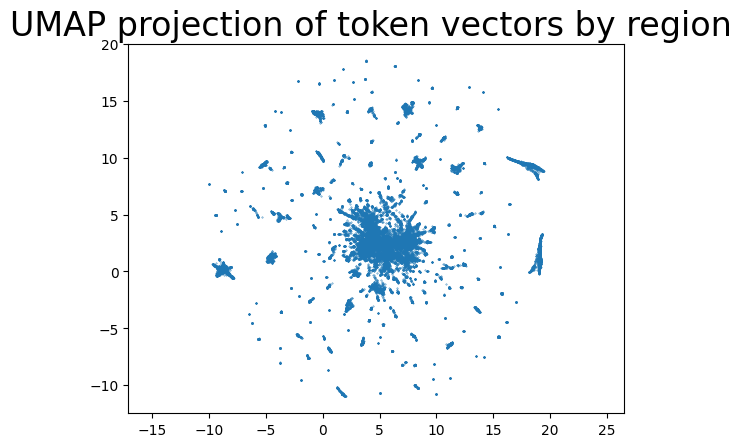

In [9]:
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=.1,
    )

    #c=[palette[i] for i in region_indices])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of token vectors by region ', fontsize=24);

In [7]:
df["x"] = embedding[:, 0]
df["y"] = embedding[:, 1]
df[["token", "region", "x", "y"]]


,token,region,x,y
0,[CLS],Jalisco,19.385399,0.719126
1,Jalisco,Jalisco,13.160749,3.531532
2,_GEO,Jalisco,14.710810,-1.731660
3,_USR,Jalisco,5.452464,11.867574
4,Se,Jalisco,3.184352,8.530391
...,...,...,...,...
30348,##I,Mexico_City,5.418265,0.625750
30349,##f,Mexico_City,6.064324,0.982064
30350,😭,Mexico_City,8.181508,5.590395
30351,_URL,Mexico_City,-1.537898,6.568278


In [11]:
import plotly.express as px
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="region",
    hover_data=["token", "region", "id_tweet"],
    title="UMAP projection of token vectors by region",
    width=1000,
    height=700
)


fig.update_traces(marker=dict(size=3, opacity=0.6), selector=dict(mode='markers'))
fig.update_layout(legend_title="Región", title_x=0.5)

fig.show()


In [12]:
from google.colab import files
fig.write_html("umap_tokens.html")
files.download("umap_tokens.html")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:

reducer3d = umap.UMAP(n_components=3, metric="cosine")
embedding_3d = reducer3d.fit_transform(X)

# Guardamos las nuevas dimensiones
df["x"] = embedding_3d[:, 0]
df["y"] = embedding_3d[:, 1]
df["z"] = embedding_3d[:, 2]


In [14]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x="x",
    y="y",
    z="z",
    color="region",  # O puedes usar "cluster"
    hover_data=["token"],
    opacity=0.6
)
fig.update_traces(marker=dict(size=1))
fig.update_layout(title="UMAP 3D projection of token vectors")
fig.show()
fig.write_html("umap_3d.html")


In [ ]:
from google.colab import files
files.download("umap_3d.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipython-input-15-2172382678.py:6: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



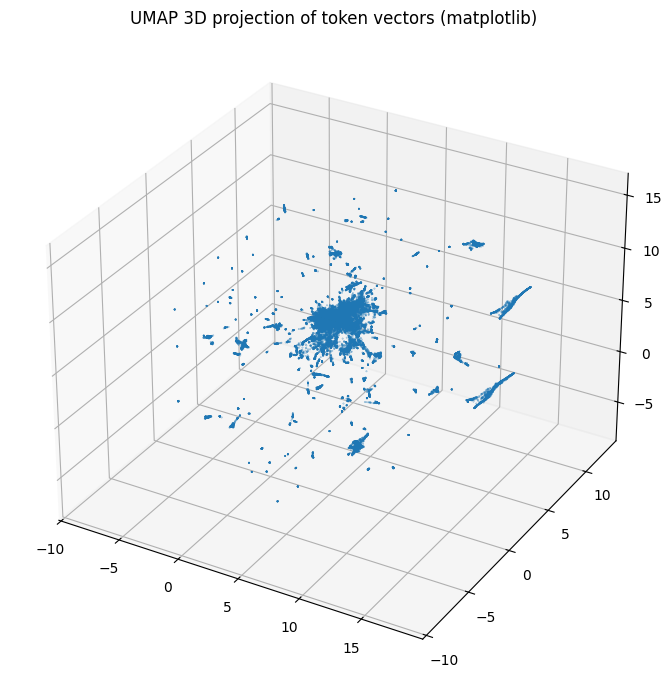

In [15]:

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df["x"],
    df["y"],
    df["z"],

    cmap="tab20",
    s=.1,
    alpha=0.6
)

ax.set_title("UMAP 3D projection of token vectors (matplotlib)")
plt.tight_layout()
plt.show()


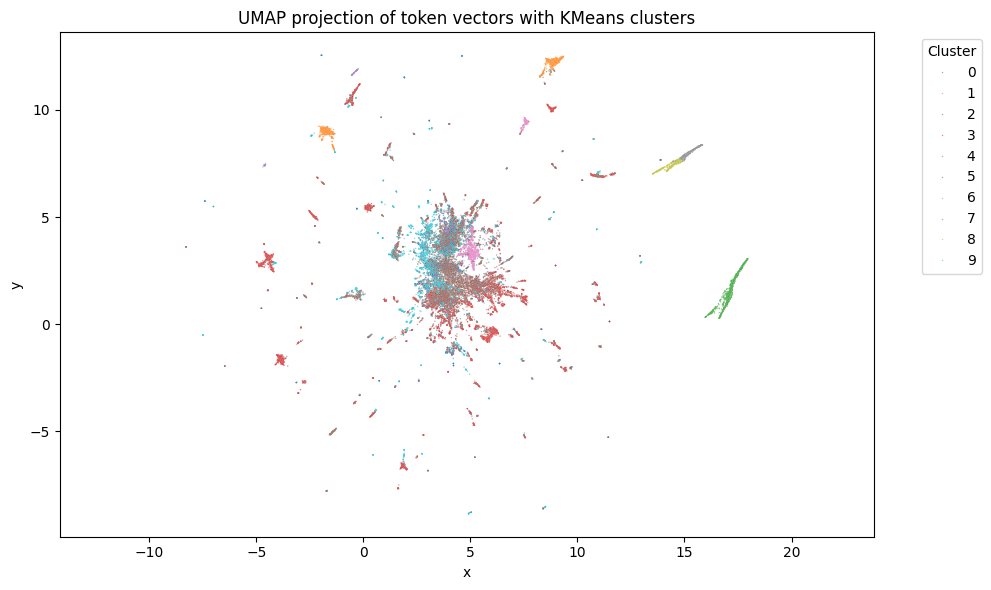

In [16]:

from sklearn.cluster import KMeans
import seaborn as sns


# Aplicar KMeans
kmeans = KMeans(n_clusters=10, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

# Visualizar sobre UMAP
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df["x"],
    y=df["y"],
    hue=df["cluster"],
    palette="tab10",
    s=1,
    alpha=0.6,
    legend="full"
)
plt.title("UMAP projection of token vectors with KMeans clusters")
plt.gca().set_aspect("equal", "datalim")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [10]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons, make_circles, make_classification, make_s_curve

In [39]:

from sklearn.preprocessing import StandardScaler

X_umap = df[["x", "y"]].values

eps = 0.5
db = DBSCAN(eps=eps, min_samples=5)
df["dbscan_cluster"] = db.fit_predict(X_umap)



In [50]:
import plotly.express as px
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="dbscan_cluster",
    title="DBSCAN clustering sobre embeddings (UMAP 2D)",
    opacity=0.7,
    hover_data=["token","region","id_tweet"]
)
fig.update_traces(marker=dict(size=2))
fig.update_layout(height=600)
fig.show()

In [45]:
print("Número de Cústeres:", df["dbscan_cluster"].nunique())


Número de Cústeres: 82


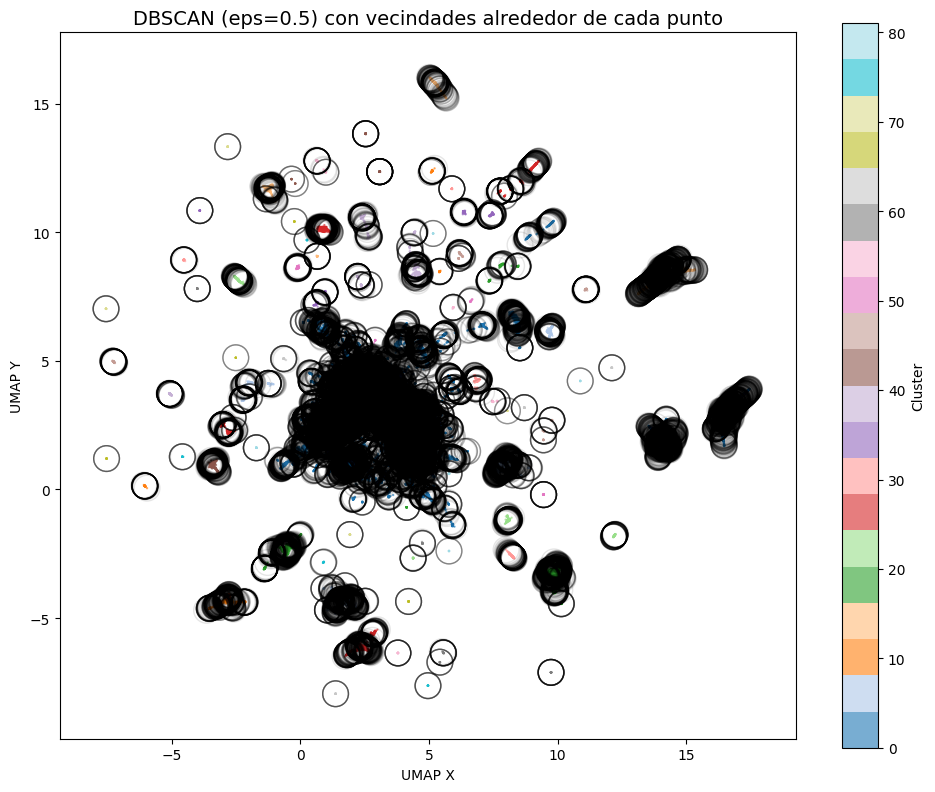

In [29]:
plt.figure(figsize=(10, 8))

# Puntos coloreados por clúster
scatter = plt.scatter(
    df["x"], df["y"],
    c=df["dbscan_cluster"],
    cmap="tab20",
    s=.5,
    alpha=0.6
)

# Dibujar un círculo eps alrededor de cada punto
for x, y in X_umap:
    circle = plt.Circle((x, y), eps, color='black', fill=False, alpha=0.1)
    plt.gca().add_patch(circle)

plt.gca().set_aspect("equal", "box")
plt.title(f"DBSCAN (eps={eps}) con vecindades alrededor de cada punto", fontsize=14)
plt.xlabel("UMAP X")
plt.ylabel("UMAP Y")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()



In [42]:
from sklearn.cluster import HDBSCAN
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons, make_circles, make_classification, make_s_curve

In [43]:
clusterer = HDBSCAN(min_cluster_size=10)
cluster_labels = clusterer.fit_predict(X_umap)

df["hdbscan_cluster"] = cluster_labels

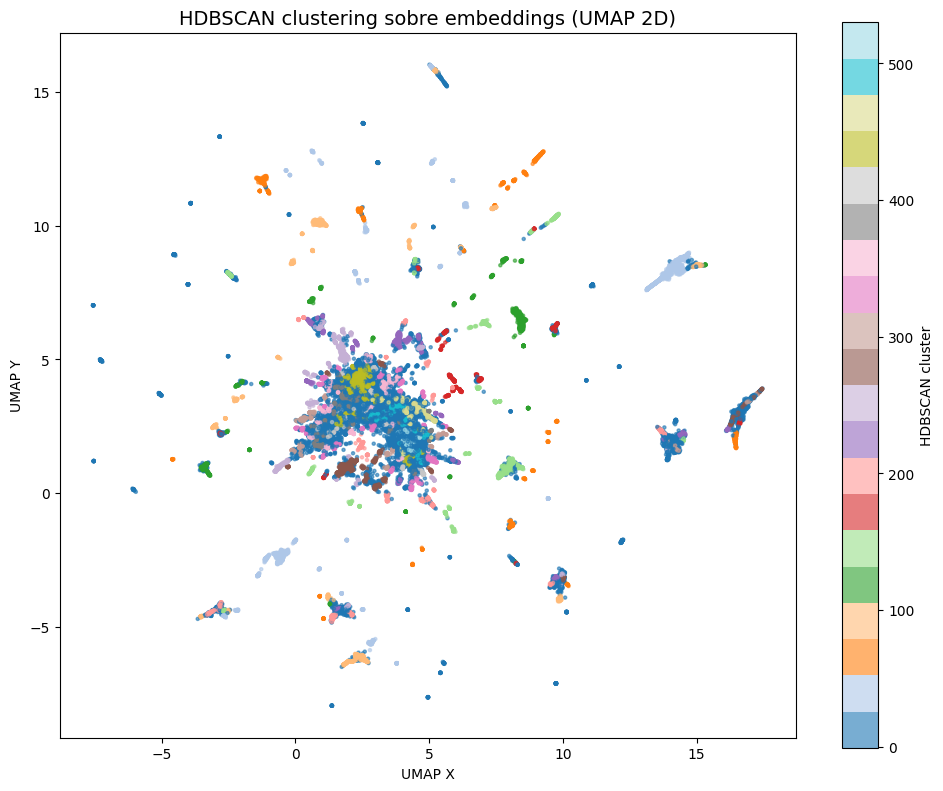

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df["x"],
    df["y"],
    c=df["hdbscan_cluster"],
    cmap="tab20",
    s=5,
    alpha=0.6
)
plt.colorbar(scatter, label="HDBSCAN cluster")
plt.title("HDBSCAN clustering sobre embeddings (UMAP 2D)", fontsize=14)
plt.xlabel("UMAP X")
plt.ylabel("UMAP Y")
plt.gca().set_aspect("equal", "box")
plt.tight_layout()
plt.show()


In [46]:
print("Número de Cústeres:", df["hdbscan_cluster"].nunique())


Número de Cústeres: 532


In [51]:
import plotly.express as px

fig = px.scatter(
    df,
    x="x",
    y="y",
    color="hdbscan_cluster",
    title="Clustering con HDBSCAN sobre embeddings (UMAP 2D)",
    opacity=0.7,
    hover_data=["token", "region","id_tweet"]
)

fig.update_traces(marker=dict(size=3))
fig.update_layout(height=600)
fig.show()
